In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

print("Everything is working")

Everything is working


In [3]:
import json

specs_fil = "../Data/afe_vary_specs.json"
with open(specs_fil, "rt") as fh:
    specs = json.load(fh)
# Common wavelength array for all of the spectra
wave = specs["wave"]
# read in first spectrum:
afe0 = specs["0"]["afe"]
spec0 = specs["0"]["spec"]

afe1 = specs["1"]["afe"]
spec1 = specs["1"]["spec"]

afe2 = specs["2"]["afe"]
spec2 = specs["2"]["spec"]

afe3 = specs["3"]["afe"]
spec3 = specs["3"]["spec"]

afe4 = specs["4"]["afe"]
spec4 = specs["4"]["spec"]

In [4]:
print(afe0, afe1, afe2, afe3, afe4)

-0.2 0.0 0.2 0.4000000000000001 0.6000000000000001


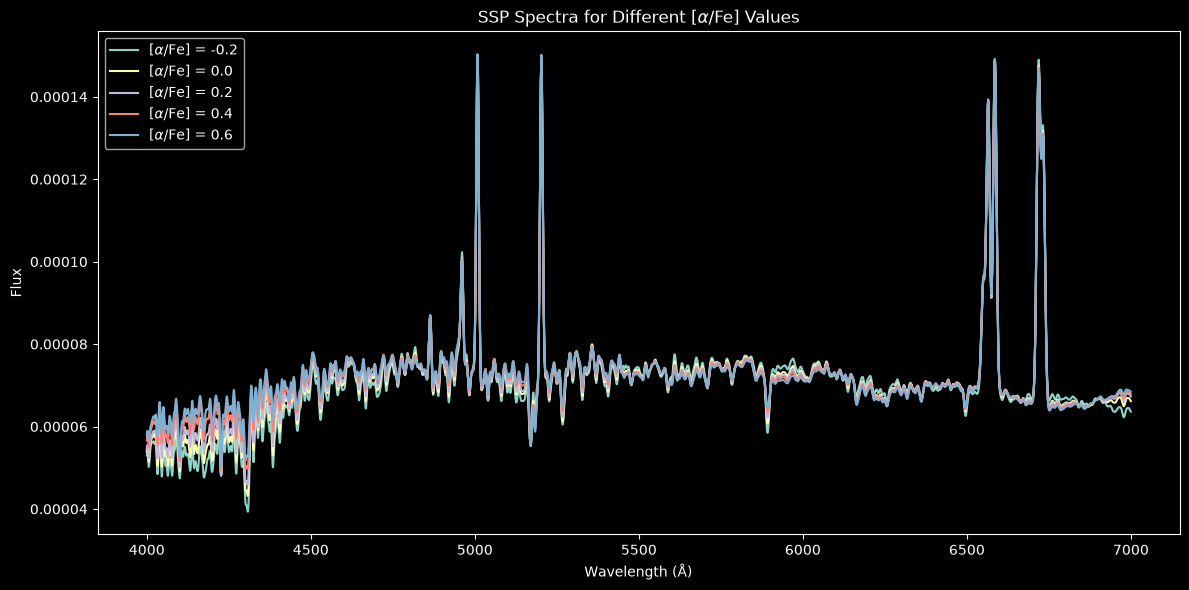

In [5]:
plt.style.use("dark_background")
plt.figure(figsize=(12, 6))
plt.plot(wave, spec0, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}")
plt.plot(wave, spec1, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe1:.1f}")
plt.plot(wave, spec2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe2:.1f}")
plt.plot(wave, spec3, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe3:.1f}")
plt.plot(wave, spec4, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe4:.1f}")

plt.xlabel(r"Wavelength ($\mathrm{\AA}$)")
plt.ylabel("Flux")
plt.title(r"SSP Spectra for Different $[\alpha/\mathrm{Fe}]$ Values")

plt.legend()
plt.tight_layout()
plt.savefig("../Figures/SSP Full Spectrum.png", dpi=300)
plt.show()

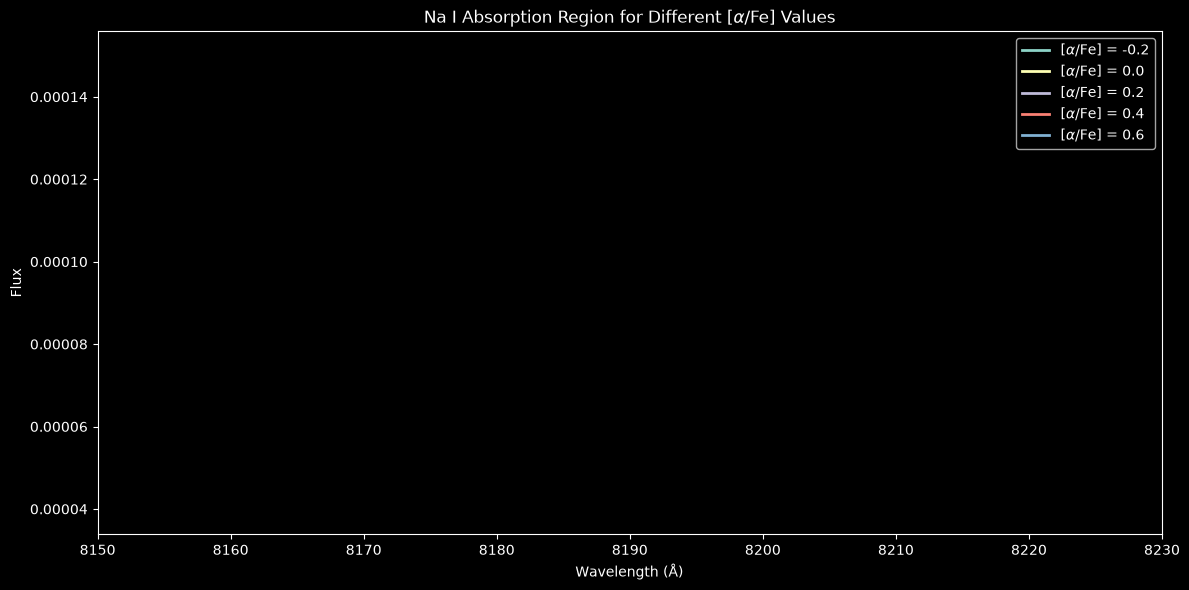

In [6]:
# Create a new figure that is 12 inches wide and 6 inches tall
plt.figure(figsize=(12, 6))

# Plot the first spectrum
plt.plot(wave, spec0, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}")

# Plot the second spectrum
plt.plot(wave, spec1, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe1:.1f}")

# Plot the third spectrum
plt.plot(wave, spec2, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe2:.1f}")

# Plot the fourth spectrum
plt.plot(wave, spec3, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe3:.1f}")

# Plot the fifth spectrum
plt.plot(wave, spec4, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe4:.1f}")

# Zoom in on the Na I absorption region
plt.xlim(8150, 8230)

# Label the x-axis
plt.xlabel(r"Wavelength ($\mathrm{\AA}$)")

# Label the y-axis
plt.ylabel("Flux")

# Add a title
plt.title(r"Na I Absorption Region for Different $[\alpha/\mathrm{Fe}]$ Values")

# Display the legend
plt.legend()

# Automatically adjust spacing
plt.tight_layout()

# Display the figure
plt.show()

In [7]:
print("Minimum wavelngth:", min(wave))
print("Maximum wavelength:", max(wave))

Minimum wavelngth: 4000.0
Maximum wavelength: 6999.700000001819


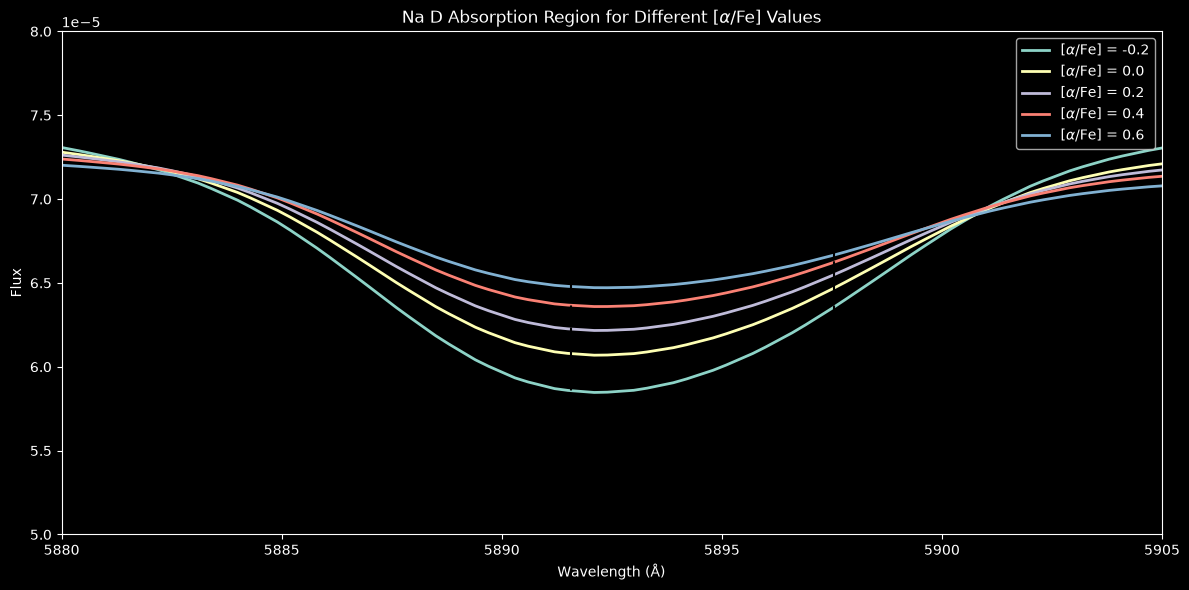

In [65]:
# Create a new figure that is 12 inches wide and 6 inches tall
plt.figure(figsize=(12, 6))

# Plot the first spectrum
plt.plot(wave, spec0, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}")

# Plot the second spectrum
plt.plot(wave, spec1, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe1:.1f}")

# Plot the third spectrum
plt.plot(wave, spec2, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe2:.1f}")

# Plot the fourth spectrum
plt.plot(wave, spec3, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe3:.1f}")

# Plot the fifth spectrum
plt.plot(wave, spec4, linewidth=2, label=rf"$[\alpha/\mathrm{{Fe}}]$ = {afe4:.1f}")

# Zoom in on the Na I absorption region
plt.xlim(5880, 5905)

# Zoom in on the y axis
plt.ylim(0.00005, 0.00008)

# Mark the two Na I D absorption-line wavelengths with vertical dashed lines
plt.axvline( 
    5891.583,
    color = "black",
    linestyle = "--",
    linewidth = 1.5,
)



plt.axvline(
    5897.558,
    color = "black",
    linestyle = "--",
    linewidth = 1.5,
)

# Label the x-axis
plt.xlabel(r"Wavelength ($\mathrm{\AA}$)")

# Label the y-axis
plt.ylabel("Flux")

# Add a title
plt.title(r"Na D Absorption Region for Different $[\alpha/\mathrm{Fe}]$ Values")

# Display the legend
plt.legend()

# Automatically adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig("../Figures/Na D Absorption Region.png", dpi=300)

# Display the figure
plt.show()

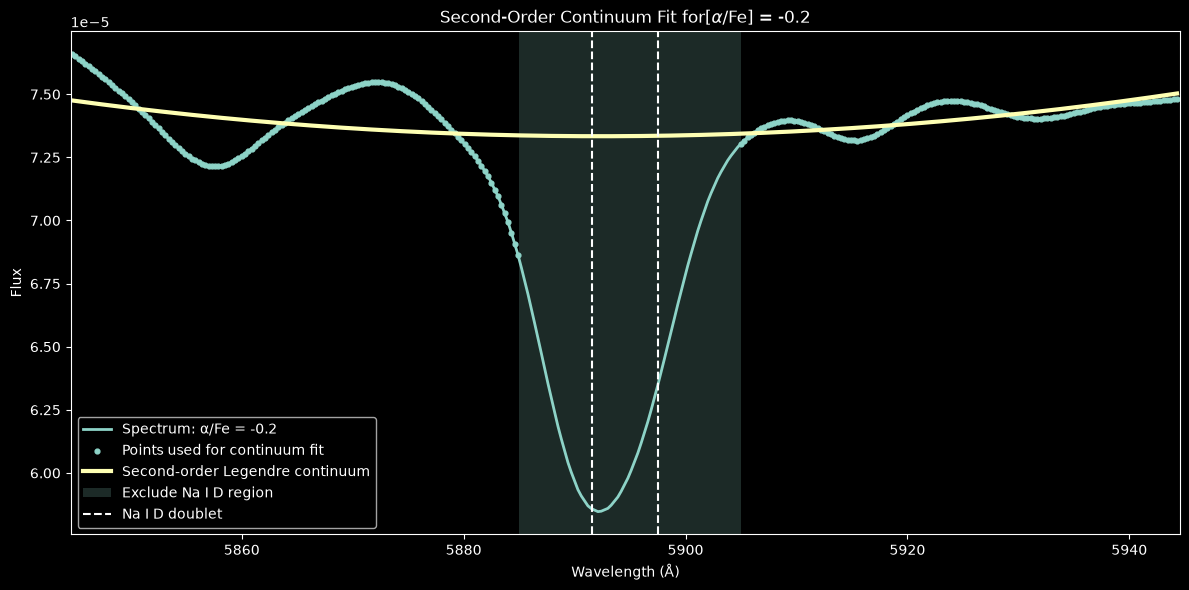

In [11]:
from numpy.polynomial import Legendre

# Convert the wavelength and spectrum into NumPy arrays
wave_array = np.array(wave)
flux_array = np.array(spec0)

# Defining the Na I D wavwelengths
na_d1 = 5891.583
na_d2 = 5897.558
 # Calculate their midpoint
na_center = (na_d1 + na_d2) / 2

# Defining the full fitting region (+ / - 50 arond the doublet)
fit_min = na_center - 50
fit_max = na_center + 50

# Create a mask (an array of True and False values) (& means both conditions must be True)
region_mask = (
    (wave_array >= fit_min)
    & (wave_array <= fit_max)
)

# Exclude the Na I D absorption region
absorption_mask = (
    (wave_array >= 5885)
    & (wave_array <= 5905)
)

# Create the continuum mask
continuum_mask = region_mask & ~absorption_mask # ~ means "Not", this line is basically saying "Keep wavelengths inside the full fitting region, but exclude wavelengths inside the absorption feature" and this is the most important part because I was specifically told by my mentor that THE ABSORPTION MUST NOT INFLUENCE THE FIT

# Select the data used for the fit, these lines select only the points where continuum_mask is True. Exctract points used in the polynomial fit
fit_wave = wave_array[continuum_mask]
fit_flux = flux_array[continuum_mask]

# Fit second-order Legendre polynomial
continuum_model = Legendre.fit( # fits a Legendre polynomial to the data
    fit_wave, # horizontal-axis data
    fit_flux, # vertical-axis data
    deg = 2 # using a second-order polynomial
)

# Evaluate the fitted continuum across the full region
region_wave = wave_array[region_mask] # contains all wavelengths in the full +/- 50 region
region_flux = flux_array[region_mask] # contains the corresponding original spectrum

continuum_flux = continuum_model(region_wave) # evaluates the fitted polynomial at every wavelength, including across the absorption feature that was excluded from the fitting process

# Create a new figure that is 12 inches wide and 6 inches tall
plt.figure(figsize=(12, 6))

# Plot the original spectrum
plt.plot(
    region_wave,
    region_flux,
    linewidth = 2,
    label = fr"Spectrum: ⍺/Fe = {afe0:.1f}"
)

# Plot the continuum points used in the fit
plt.scatter(
    fit_wave,
    fit_flux,
    s = 12,
    label = "Points used for continuum fit"
)

# Plot the fitted Legendre continuum and or Overplot (one graph on top of another graph in the same figure) the fitted continuum
plt.plot(
    region_wave,
    continuum_flux,
    linewidth = 3,
    label = "Second-order Legendre continuum"
)

# Shade the region excluded from the fit
plt.axvspan(
    5885,
    5905,
    alpha = 0.2,
    label = "Exclude Na I D region"
)

# Mark the two Na I D wavelengths
plt.axvline(
    na_d1,
    linestyle = "--",
    linewidth = 1.5
)

plt.axvline(
    na_d2,
    linestyle = "--",
    linewidth = 1.5,
    label = "Na I D doublet"
)

# Show the full continuum-fitting region
plt.xlim(fit_min, fit_max)

# Label the axes
plt.xlabel ("Wavelength (Å)")
plt.ylabel("Flux")

# Add a title 
plt.title(fr"Second-Order Continuum Fit for"
          fr"$[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}"
)
# Add the legend
plt.legend() # little key or box on a graph that explains what each line, color, or symbol represents

# Fix spacing
plt.tight_layout()

# Save figure
plt.savefig("../Figures/Na D Continuum Fit afe0.png", dpi = 300)

# Display figure
plt.show()

In [12]:
import specutils
print(specutils.__version__)

2.4.0


In [13]:
import astropy.units as u
from specutils.utils.wcs_utils import air_to_vac
from numpy.polynomial import Legendre

# Convert the original wavelength list into a NumPy array
wave_air = np.array(wave) # This converts my original JSON wavelength list into a NumPy array

# Attach angstrom units to the air-wavelength array (* u.AA)
wave_air_quantity = wave_air * u.AA

# Convert the wavelengths from air to vacuum
wave_vac_quantity = air_to_vac(wave_air_quantity) # air-to-vacuum conversion for every wavelength in the array

# Remove the Astropy unit object while keeping the values in angstroms
wave_array = wave_vac_quantity.to_value(u.AA)

# Convert the first spectrum into a Numpy array
flux_array = np.array(spec0) # Wavelength convention changes, but the values do not. Therefore only convert the x-axis array, NOT the spectrum itself

In [14]:
# Verifying conversion
print("First five air wavelengths:")
print(wave_air[:5])

print("\nFirst five vacuum wavelengths:")
print(wave_array[:5])

print("\nDifference between vacuum and air:")
print((wave_array - wave_air)[:5])

First five air wavelengths:
[4000.  4000.3 4000.6 4000.9 4001.2]

First five vacuum wavelengths:
[4001.13104547 4001.43112385 4001.73120222 4002.0312806  4002.33135897]

Difference between vacuum and air:
[1.13104547 1.13112385 1.13120222 1.1312806  1.13135897]


In [15]:
# Checking region around sodium
nearest_index = np.argmin(np.abs(wave_air - 5890)) # Calculates how far every wavelength is from 5890. np.argmin() returns the position of the smallest difference, meaning the wavelength closest to 5890

print("Air wavelength:", wave_air[nearest_index], "Å")
print("Vacuum wavelength:", wave_array[nearest_index], "Å")

Air wavelength: 5890.000000001146 Å
Vacuum wavelength: 5891.632427627092 Å


In [16]:
# Define the vacuum wavelengths of the Na I D doublet
na_d1 = 5891.583
na_d2 = 5897.558

# Calculate the midpoint of the doublet
na_center = (na_d1 + na_d2) / 2

# Define the fitting region as plus or minus 50 angstroms
fit_min = na_center - 50
fit_max = na_center + 50

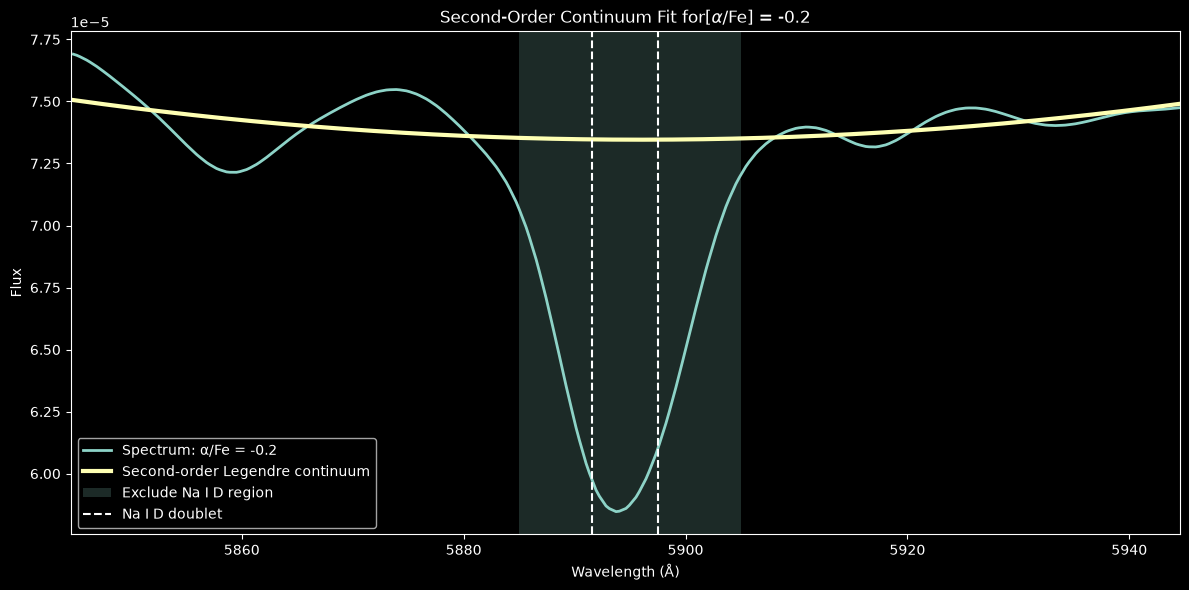

In [17]:
# Create a mask (an array of True and False values) (& means both conditions must be True)
region_mask = (
    (wave_array >= fit_min)
    & (wave_array <= fit_max)
)

# Exclude the Na I D absorption region
absorption_mask = (
    (wave_array >= 5885)
    & (wave_array <= 5905)
)

# Create the continuum mask
continuum_mask = region_mask & ~absorption_mask # ~ means "Not", this line is basically saying "Keep wavelengths inside the full fitting region, but exclude wavelengths inside the absorption feature" and this is the most important part because I was specifically told by my mentor that THE ABSORPTION MUST NOT INFLUENCE THE FIT

# Select the data used for the fit, these lines select only the points where continuum_mask is True. Exctract points used in the polynomial fit
fit_wave = wave_array[continuum_mask]
fit_flux = flux_array[continuum_mask]

# Fit Legendre polynomial (1-6 orders)
continuum_model = Legendre.fit( # fits a Legendre polynomial to the data
    fit_wave, # horizontal-axis data
    fit_flux, # vertical-axis data
    deg = 2 # using a 1-6 order polynomial (whatever number I want)
)

# Evaluate the fitted continuum across the full region
region_wave = wave_array[region_mask] # contains all wavelengths in the full +/- 50 region
region_flux = flux_array[region_mask] # contains the corresponding original spectrum

continuum_flux = continuum_model(region_wave) # evaluates the fitted polynomial at every wavelength, including across the absorption feature that was excluded from the fitting process

# Create a new figure that is 12 inches wide and 6 inches tall
plt.figure(figsize=(12, 6))

# Plot the original spectrum
plt.plot(
    region_wave,
    region_flux,
    linewidth = 2,
    label = fr"Spectrum: ⍺/Fe = {afe0:.1f}"
)

# Plot the continuum points used in the fit
 # Removing this code
 # plt.scatter(
    #fit_wave,
    #fit_flux,
    #s = 12,
    #label = "Points used for continuum fit"
    #)

# Plot the fitted Legendre continuum and or Overplot (one graph on top of another graph in the same figure) the fitted continuum
plt.plot(
    region_wave,
    continuum_flux,
    linewidth = 3,
    label = "Second-order Legendre continuum"
)

# Shade the region excluded from the fit
plt.axvspan(
    5885,
    5905,
    alpha = 0.2,
    label = "Exclude Na I D region"
)

# Mark the two Na I D wavelengths
plt.axvline(
    na_d1,
    linestyle = "--",
    linewidth = 1.5
)

plt.axvline(
    na_d2,
    linestyle = "--",
    linewidth = 1.5,
    label = "Na I D doublet"
)

# Show the full continuum-fitting region
plt.xlim(fit_min, fit_max)

# Label the axes
plt.xlabel ("Wavelength (Å)")
plt.ylabel("Flux")

# Add a title 
plt.title(fr"Second-Order Continuum Fit for"
          fr"$[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}"
)
# Add the legend
plt.legend() # little key or box on a graph that explains what each line, color, or symbol represents

# Fix spacing
plt.tight_layout()

# Save figure
plt.savefig("../Figures/Na D Continuum deg2 Fit afe0 vacuum.png", dpi = 300)

# Display figure
plt.show()

In [18]:
# Divide the original spectrum by the fitted continuum
normalized_flux = region_flux / continuum_flux
print(normalized_flux)

[1.02462661 1.02431566 1.02377745 1.02312465 1.02247002 1.02164109
 1.02072398 1.01980494 1.01876987 1.01767576 1.01657962 1.0154323
 1.01425835 1.01308236 1.01188015 1.01066381 1.00944543 1.00820035
 1.00694089 1.00567939 1.00437262 1.00304218 1.00170967 1.00031691
 0.99889296 0.99746693 0.99597632 0.99445237 0.9929263  0.99135361
 0.98975654 0.98815735 0.98656449 0.98497375 0.98338091 0.98185939
 0.98037252 0.97888361 0.97756332 0.9763264  0.97508756 0.97410476
 0.97324915 0.97239176 0.97185138 0.97146877 0.97108457 0.97106829
 0.97123534 0.97140101 0.9719389  0.97266236 0.97338463 0.97439591
 0.97555122 0.97670547 0.97806305 0.97952185 0.98097968 0.98254047
 0.98415228 0.98576316 0.98737126 0.9889775  0.99058278 0.99212998
 0.99364762 0.99516425 0.99659399 0.99797975 0.99936445 1.00067215
 1.0019408  1.00320832 1.00442357 1.00561211 1.00679948 1.00795192
 1.00908631 1.01021951 1.01131945 1.01240215 1.01348362 1.01451637
 1.01552412 1.01653061 1.01745836 1.01834608 1.01923249 1.01998

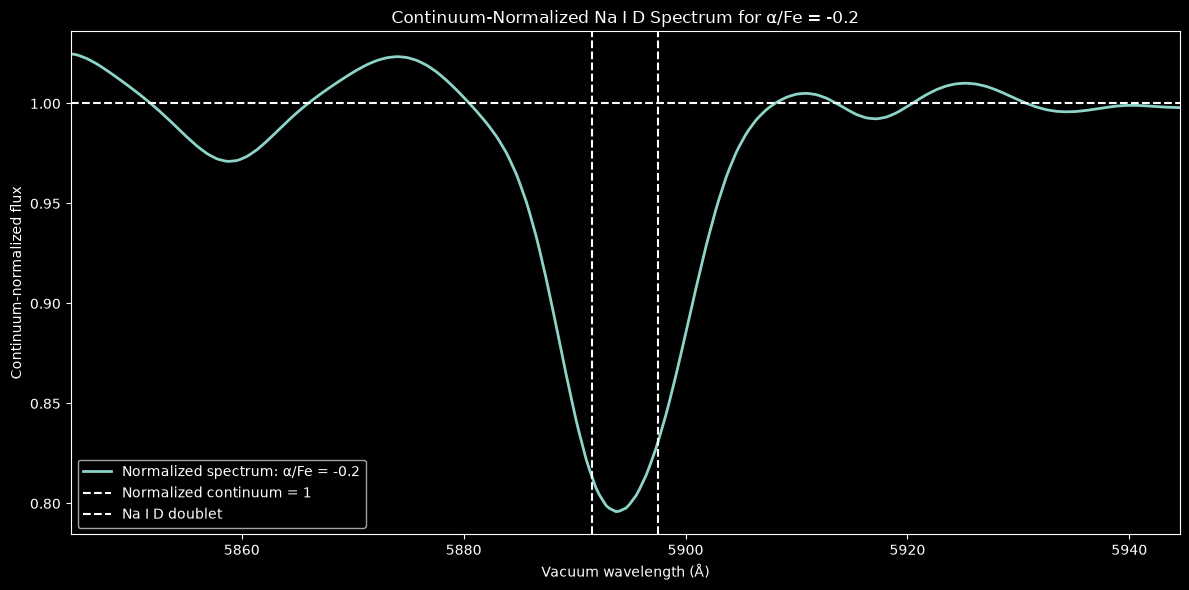

In [19]:
# Create new figure
plt.figure(figsize=(12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Draw a horizontal line at the continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Normalized continuum = 1"
)

# Mark the two Na I D vacuum wavelengths
plt.axvline(
    na_d1,
    linestyle = "--",
    linewidth = 1.5
)

plt.axvline(
    na_d2,
    linestyle = "--",
    linewidth = 1.5,
    label = "Na I D doublet"
)

# Display the continuum-fitting wavelength interval
plt.xlim(fit_min, fit_max)

# Label the axes
plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")

# Add a title
plt.title(
    f"Continuum-Normalized Na I D Spectrum for ⍺/Fe = {afe0:.1f}"
)

# Display the legend
plt.legend()

# Fix figure spacing
plt.tight_layout()

# Save the figure
plt.savefig(
    "../Figures/Na D Normalized Spectrum afe0.png",
    dpi = 300
)

# Display the figure
plt.show()

In [22]:
# Trial values for the blue Na I D line
amplitude_blue = 0.12 # This controls the depth of the blue line. At its center, the model is approx. 1 - 0.12 = 0.88 so the line removes 12% of the continuum light before overlap with the red component.

sigma_sys = 4.0 # This controls the width of the line in angstroms. A larger sigma_sys gives a broader dip. A smaller value gives a narrower dip.

# Fixed vacuum wavelength of the blue line
lambda_blue = 5891.583 # Fixes the center of the blue memeber of the Na I D doublet

# Build the blue Gaussian absorption component
blue_component = 1 - amplitude_blue * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys ** 2)
)

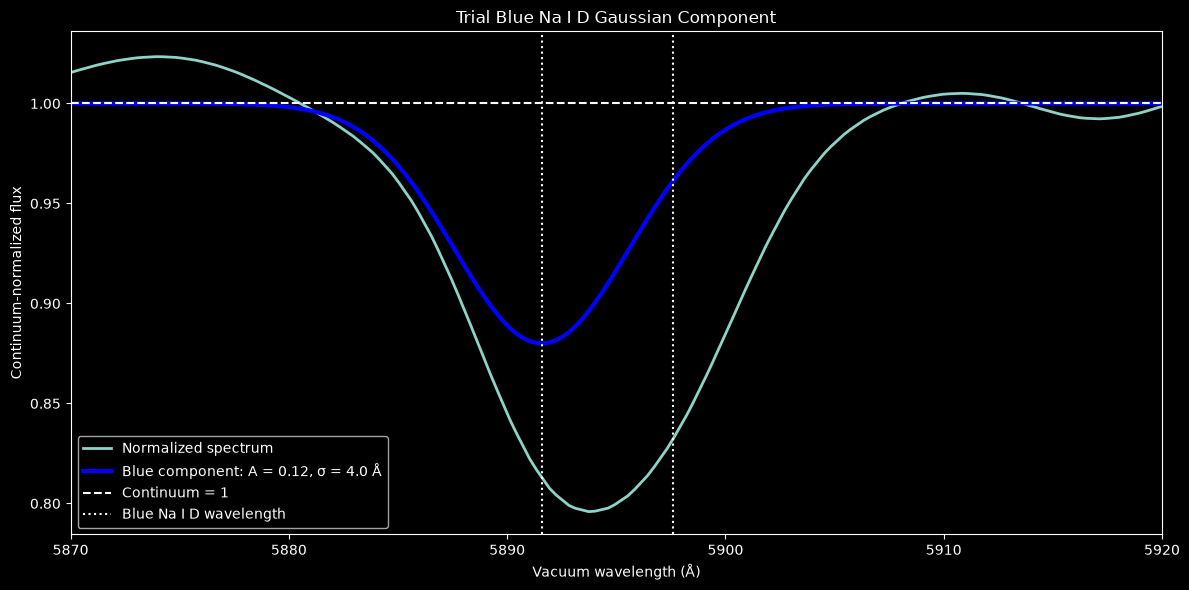

In [25]:
# Plotting the blue component alone
plt.figure(figsize = (12, 6))

plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = "Normalized spectrum"
)

plt.plot(
    region_wave,
    blue_component,
    linewidth = 3,
    color = "blue",
    label = (
        f"Blue component: "
        f"A = {amplitude_blue:.2f}, "
        f"σ = {sigma_sys:.1f} Å"
    )
)
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Blue Na I D wavelength"
)

plt.xlim(5870, 5920)
plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial Blue Na I D Gaussian Component")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../Figures/Trial Blue Na I D Gaussian Component afe0.png",
    dpi = 300
)
plt.show()

In [26]:
# Creating the red absorption line
# Trial value for the red Na I D line
amplitude_red = 0.08 # controls the red line's depth

# Fixed vacuum wavelength of the red line
lambda_red = 5897.588 # fixes its center

# Build the red Gaussian absorprtion component
red_component = 1 - amplitude_red * np.exp(
    -((region_wave - lambda_red) ** 2) / (2 * sigma_sys ** 2)
)

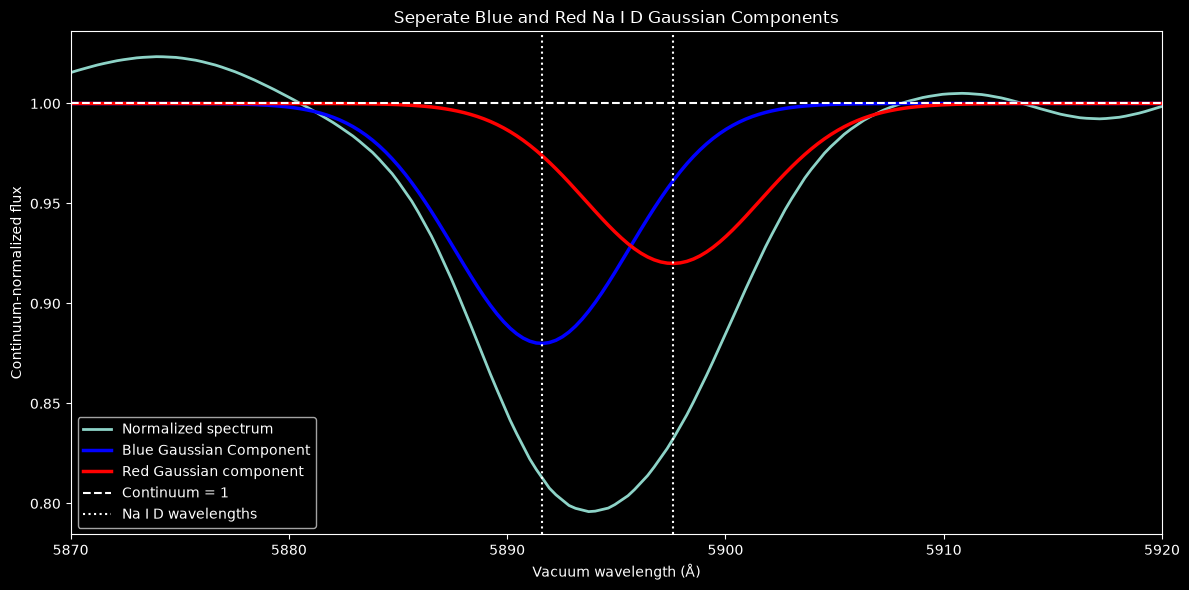

In [27]:
# Plotting both components seperately
plt.figure(figsize = (12, 6))

plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = "Normalized spectrum"
)

plt.plot(
    region_wave,
    blue_component,
    linewidth = 2.5,
    color = "blue",
    label = "Blue Gaussian Component"
)

plt.plot(
    region_wave,
    red_component,
    linewidth = 2.5,
    color = "red",
    label = "Red Gaussian component"
)

plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5
)

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D wavelengths"
)

plt.xlim(5870, 5920)
plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Seperate Blue and Red Na I D Gaussian Components")
plt.legend()
plt.tight_layout()
plt.savefig(
    "../Figures/Seperate Blue & Red Gaussian Components afe0.png",
    dpi = 300
)
plt.show()

In [28]:
double_gaussian_trial1 = blue_component * red_component

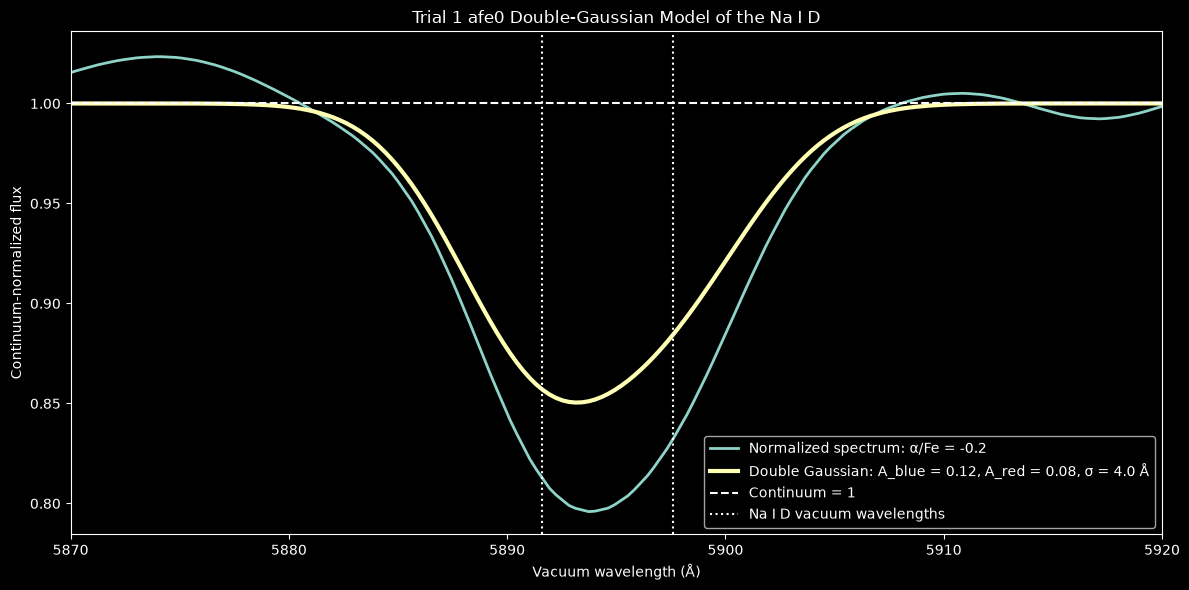

In [29]:
# Overplot of full model
plt.figure(figsize = (12, 6))

# Original normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Combined double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial1,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue:.2f}, "
        f"A_red = {amplitude_red:.2f}, "
        f"σ = {sigma_sys:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
lambda_red,
linestyle = ":",
linewidth = 1.5
)

plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 1 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 1 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()

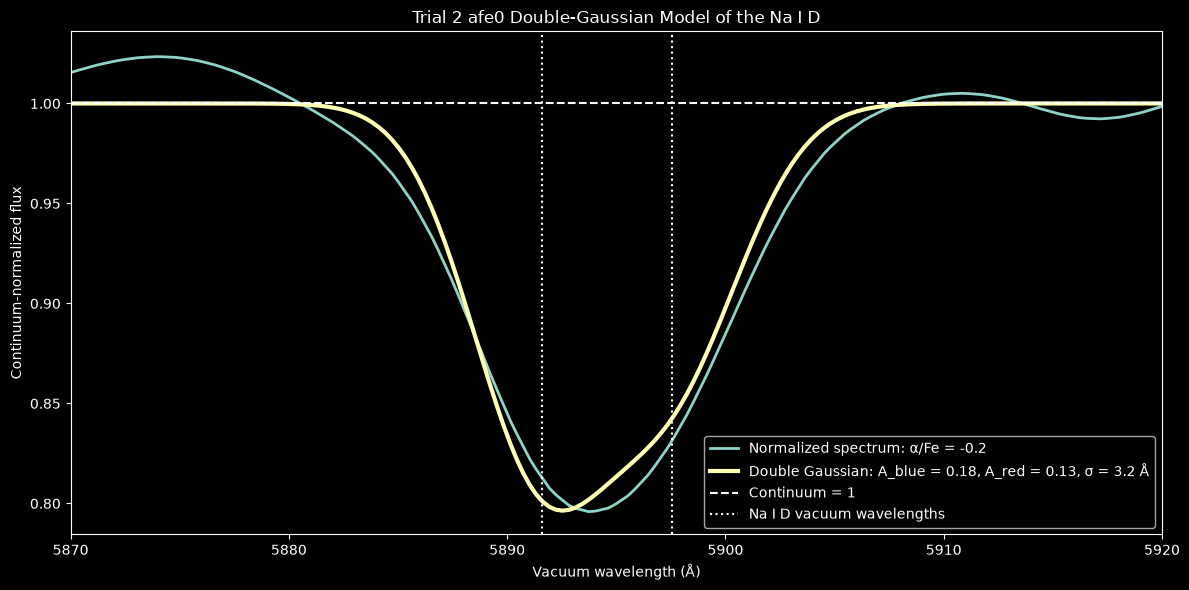

In [30]:
# Second trial for Double-Gaussian Model

# Trial 2 parameter values
amplitude_blue_trial2 = 0.18 # How deep the blue line is
amplitude_red_trial2 = 0.13 # How deep the red line is
sigma_sys_trial2 = 3.2 # How deep both lines are

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial2= 1 - amplitude_blue_trial2 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial2 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial2 = 1 - amplitude_red_trial2 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial2 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial2 = (
    blue_component_trial2 * red_component_trial2
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Overplot the Trial 2 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial2,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial2:.2f}, "
        f"A_red = {amplitude_red_trial2:.2f}, "
        f"σ = {sigma_sys_trial2:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 2 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 2 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()

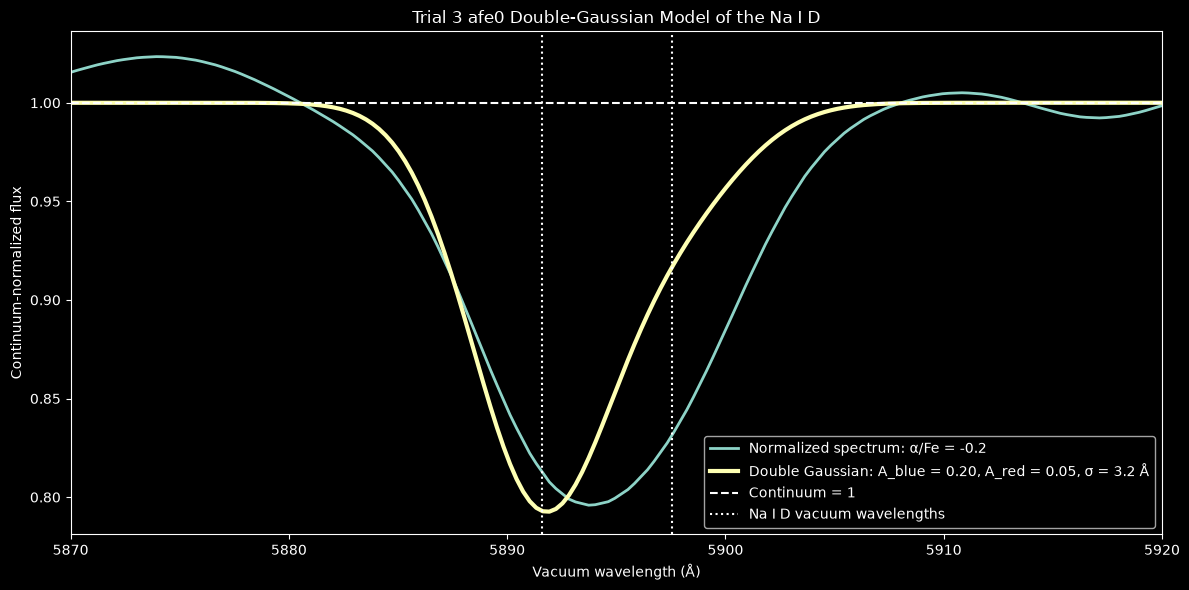

In [31]:
# Trail 3 for Double-Gaussian model

# Trial 3 parameter values
amplitude_blue_trial3 = 0.2
amplitude_red_trial3 = 0.05
sigma_sys_trial3 = 3.2 # kept same as trial 2

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial3= 1 - amplitude_blue_trial3 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial3 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial3 = 1 - amplitude_red_trial3 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial3 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial3 = (
    blue_component_trial3 * red_component_trial3
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Overplot the Trial 3 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial3,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial3:.2f}, "
        f"A_red = {amplitude_red_trial3:.2f}, "
        f"σ = {sigma_sys_trial3:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 3 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 3 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()

In [32]:
print("Blue amplitude:", amplitude_blue_trial3)
print("Red amplitude:", amplitude_red_trial3)
print("Sigma:", sigma_sys_trial3)
print("Minimum model flux:", np.min(double_gaussian_trial3))

Blue amplitude: 0.2
Red amplitude: 0.05
Sigma: 3.2
Minimum model flux: 0.7926461197388711


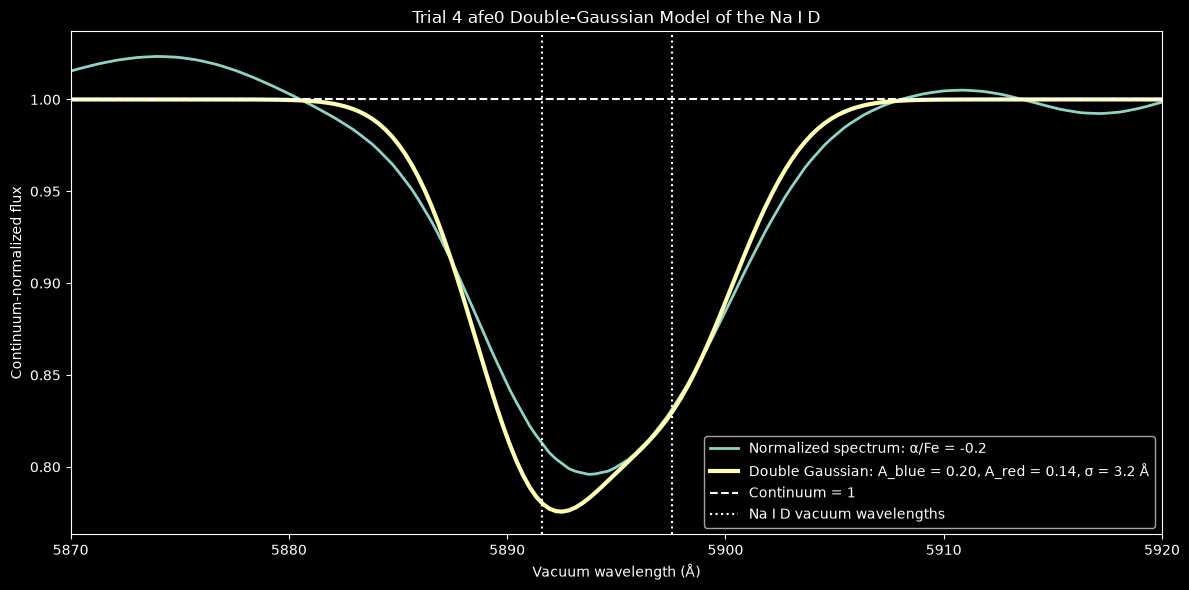

In [33]:
# Trial 4 Double-Gaussian model
# Trial 4 parameter values
amplitude_blue_trial4 = 0.2
amplitude_red_trial4 = 0.14
sigma_sys_trial4 = 3.2 # kept same as trial 2 & 3

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial4= 1 - amplitude_blue_trial4 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial4 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial4 = 1 - amplitude_red_trial4 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial4 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial4 = (
    blue_component_trial4 * red_component_trial4
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Overplot the Trial 4 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial4,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial4:.2f}, "
        f"A_red = {amplitude_red_trial4:.2f}, "
        f"σ = {sigma_sys_trial4:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 4 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 4 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()

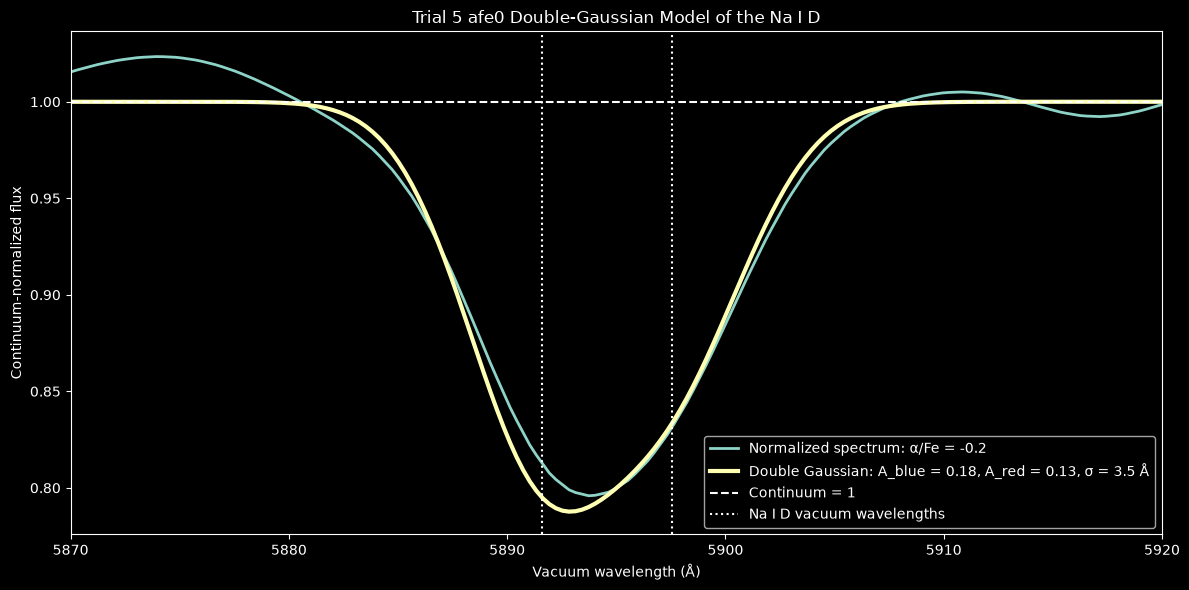

In [34]:
# Trial 5 Double-Gaussian model
# Trial 5 parameter values
amplitude_blue_trial5 = 0.18
amplitude_red_trial5 = 0.13
sigma_sys_trial5 = 3.5

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial5= 1 - amplitude_blue_trial5 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial5 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial5 = 1 - amplitude_red_trial5 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial5 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial5 = (
    blue_component_trial5 * red_component_trial5
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Overplot the Trial 5 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial5,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial5:.2f}, "
        f"A_red = {amplitude_red_trial5:.2f}, "
        f"σ = {sigma_sys_trial5:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 5 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 5 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()

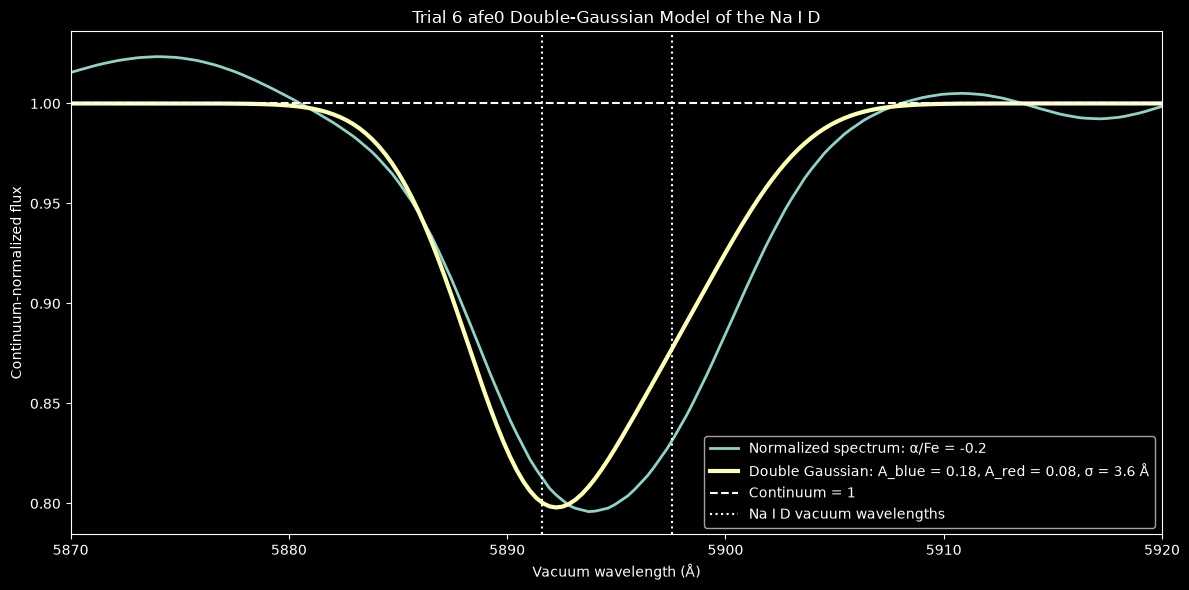

In [35]:
plt.style.use("dark_background") # Changes figure background color from white to black
# Trial 6 Double-Gaussian model
# Trial 6 parameter values
amplitude_blue_trial6 = 0.183
amplitude_red_trial6 = 0.08
sigma_sys_trial6 = 3.6

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial6= 1 - amplitude_blue_trial6 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial6 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial6 = 1 - amplitude_red_trial6 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial6 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial6 = (
    blue_component_trial6 * red_component_trial6
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Overplot the Trial 6 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial6,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial6:.2f}, "
        f"A_red = {amplitude_red_trial6:.2f}, "
        f"σ = {sigma_sys_trial6:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 6 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Trial 6 afe0 Na D Double Gaussian afe0.png",
    dpi = 300
)

plt.show()


In [36]:
print(afe0)

-0.2


In [37]:
print(afe1)

0.0


In [38]:
print(afe2)

0.2


In [39]:
print(afe3)

0.4000000000000001


In [40]:
print(afe4)

0.6000000000000001


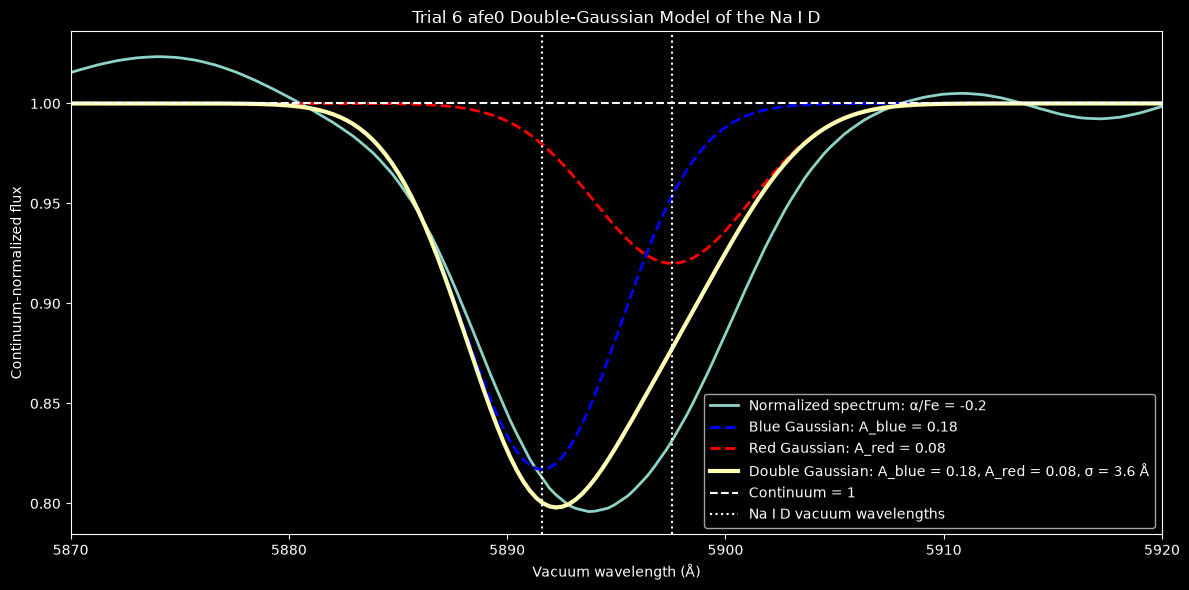

In [41]:
# Showing the blue and red Gaussian components

plt.style.use("dark_background") # Changes figure background color from white to black
# Trial 6 Double-Gaussian model
# Trial 6 parameter values
amplitude_blue_trial6 = 0.183 # How deep the blue line is
amplitude_red_trial6 = 0.08 # How deep the red line is
sigma_sys_trial6 = 3.6 # How wide both lines are

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial6= 1 - amplitude_blue_trial6 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial6 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial6 = 1 - amplitude_red_trial6 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial6 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial6 = (
    blue_component_trial6 * red_component_trial6
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Adding the blue Gaussian component
plt.plot(
    region_wave,
    blue_component_trial6,
    linewidth = 2,
    linestyle = "--",
    color = "blue",
    label = f"Blue Gaussian: A_blue = {amplitude_blue_trial6:.2f}"
)

# Adding the red Gaussian component
plt.plot(
    region_wave,
    red_component_trial6,
    linewidth = 2,
    linestyle = "--",
    color = "red",
    label = f"Red Gaussian: A_red = {amplitude_red_trial6:.2f}"
)

# Overplot the Trial 6 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial6,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial6:.2f}, "
        f"A_red = {amplitude_red_trial6:.2f}, "
        f"σ = {sigma_sys_trial6:.1f} Å"
    )
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 6 afe0 Double-Gaussian Model of the Na I D")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Updated Trial 6 afe0 Na D Double Gaussian with Blue and Red Components afe0.png",
    dpi = 300
)

plt.show()


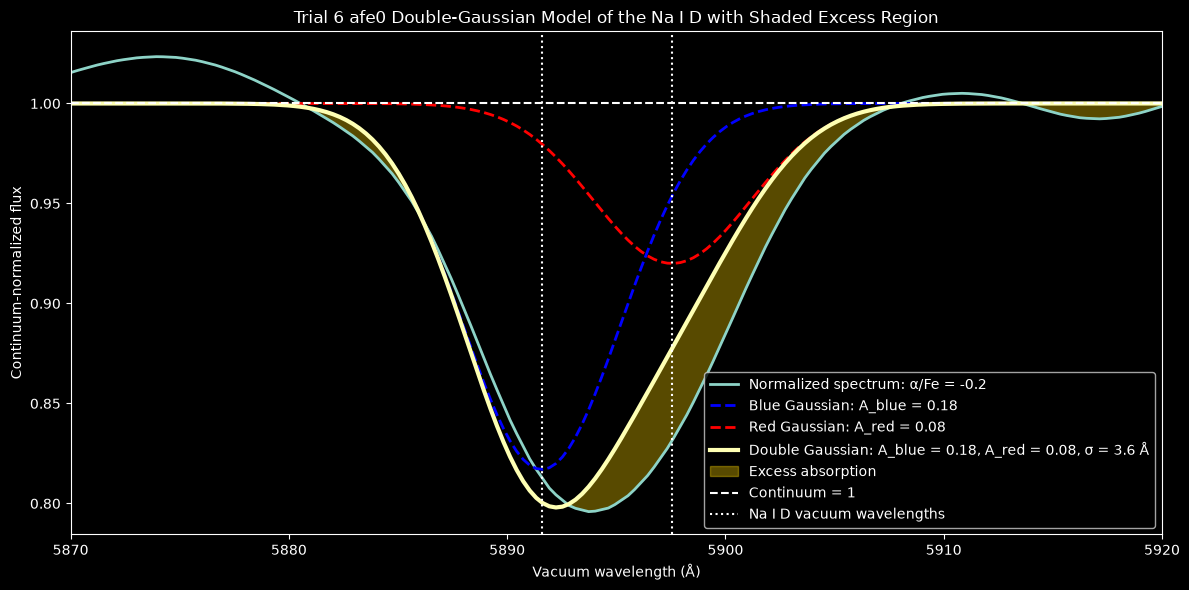

In [43]:
# Shading the excess region of best trial figure

# Showing the blue and red Gaussian components

plt.style.use("dark_background") # Changes figure background color from white to black
# Trial 6 Double-Gaussian model
# Trial 6 parameter values
amplitude_blue_trial6 = 0.183 # How deep the blue line is
amplitude_red_trial6 = 0.08 # How deep the red line is
sigma_sys_trial6 = 3.6 # How wide both lines are

# Fixed vacuum wavelengths of the Na I D doublet
lambda_blue = 5891.583
lambda_red = 5897.558

# Create the blue Gaussian absorption component
blue_component_trial6= 1 - amplitude_blue_trial6 * np.exp(
    -((region_wave - lambda_blue) ** 2) / (2 * sigma_sys_trial6 ** 2)
)

# Create the red Gaussian absorption component
red_component_trial6 = 1 - amplitude_red_trial6 * np.exp(
    -((region_wave - lambda_red) **2) / (2 * sigma_sys_trial6 ** 2)
)

# Multiply the two components to produce Equation C1
double_gaussian_trial6 = (
    blue_component_trial6 * red_component_trial6
)

# Create figure
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave,
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)

# Adding the blue Gaussian component
plt.plot(
    region_wave,
    blue_component_trial6,
    linewidth = 2,
    linestyle = "--",
    color = "blue",
    label = f"Blue Gaussian: A_blue = {amplitude_blue_trial6:.2f}"
)

# Adding the red Gaussian component
plt.plot(
    region_wave,
    red_component_trial6,
    linewidth = 2,
    linestyle = "--",
    color = "red",
    label = f"Red Gaussian: A_red = {amplitude_red_trial6:.2f}"
)

# Overplot the Trial 6 Double-Gaussian model
plt.plot(
    region_wave,
    double_gaussian_trial6,
    linewidth = 3,
    label = (
        f"Double Gaussian: "
        f"A_blue = {amplitude_blue_trial6:.2f}, "
        f"A_red = {amplitude_red_trial6:.2f}, "
        f"σ = {sigma_sys_trial6:.1f} Å"
    )
)

# Shading the region
plt.fill_between( # colors area between two lines because fill_between needs two lines
    region_wave, # x-axis to shade
    normalized_flux, # first boundary of the shaded region
    double_gaussian_trial6, # second boundary of the shaded region
    where = (normalized_flux < double_gaussian_trial6), # normalized_flux = observed spectrum. double_gaussian = fitted stellar model, shade the observed spectrum that's less than the fitted stellar model
    interpolate = True, # Matplotlib estimates exactly where the two curves intersect, the shading ends smoothly at that estiamted crossing
    color = "gold",
    alpha = 0.35, # Trasnparency of shaded color
    label = "Excess absorption"
)

# Continuum level
plt.axhline(
    1.0,
    linestyle = "--",
    linewidth = 1.5,
    label = "Continuum = 1"
)

# Doublet wavelengths

plt.axvline(
    lambda_red,
    linestyle = ":",
    linewidth = 1.5
)
plt.axvline(
    lambda_blue,
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Zoom in on the Na I D region
plt.xlim(5870, 5920)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")
plt.title("Trial 6 afe0 Double-Gaussian Model of the Na I D with Shaded Excess Region")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Figures/Updated Trial 6 afe0 Na D Double Gaussian with Blue and Red Components and Shaded Excess Region.png",
    dpi = 300
)

plt.show()


In [44]:
from scipy.optimize import curve_fit # curve_fit automatically finds the best values

In [45]:
def func(x, A_blue, sig_blue, A_red, sig_red): # Automatically finds parameters
    # Create the blue Gaussian absorption component
    lambda_blue = 5891.583
    lambda_red = 5897.558
    blue_component = 1 - A_blue * np.exp(
        -((x - lambda_blue) ** 2) / (2 * sig_blue ** 2)
    )
    # Create the red Gaussian absorption component
    red_component = 1 - A_red * np.exp(
        -((x - lambda_red) **2) / (2 * sig_red ** 2)
    )

    # Multiply the two components to produce Equation C1
    double_gaussian = blue_component * red_component

    return double_gaussian


In [46]:
popt, pcov = curve_fit(func, region_wave, normalized_flux, p0 = [0.183, 3.6, 0.08, 3.6]) # parameter guesses
# popt means optimized parameters
# pcov means covariance matrix, it contains informartion about the estimated uncertainties and relationships among the fitted parameters

In [47]:
print(popt)

[0.15568282 3.84562197 0.12920738 3.77447062]


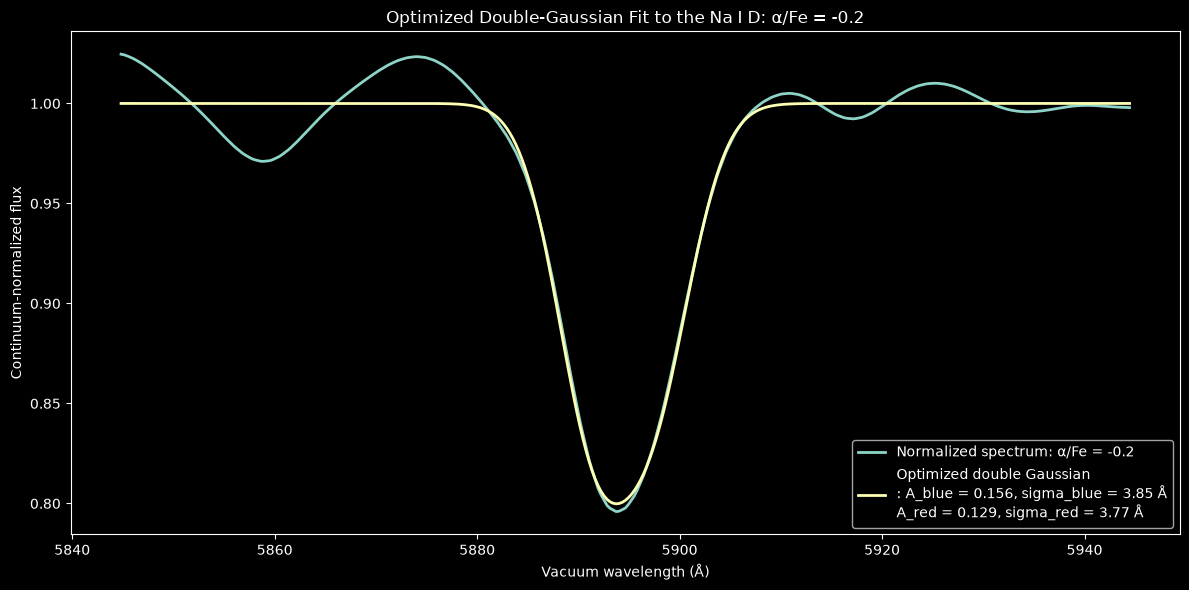

In [48]:
# create a new plot with new paramaters
plt.style.use("dark_background")
plt.figure(figsize = (12, 6))

# Plot the continuum-normalized spectrum
plt.plot(
    region_wave, # x values
    normalized_flux,
    linewidth = 2,
    label = f"Normalized spectrum: ⍺/Fe = {afe0:.1f}"
)
# create the optimized fit
gauss_fit = func(region_wave, popt[0], popt[1], popt[2], popt[3]) # y values I want to plot

# plot the optimized double-Gaussian fit
plt.plot( # plots the yellow fitted model
    region_wave,
    gauss_fit,
    linewidth = 2,
    label = (f"Optimized double Gaussian\n: "
            f"A_blue = {popt[0]:.3f}, sigma_blue = {popt[1]:.2f} Å\n"
            f"A_red = {popt[2]:.3f}, sigma_red = {popt[3]:.2f} Å"
    )
)

plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Continuum-normalized flux")

plt.title(
    f"Optimized Double-Gaussian Fit to the Na I D: ⍺/Fe = {afe0:.1f}"
)

plt.legend(loc = "lower right")

plt.tight_layout()

plt.savefig(
    "../Figures/Optimized Double Gaussian Fit afe0.png",
    dpi = 300
)

plt.show()

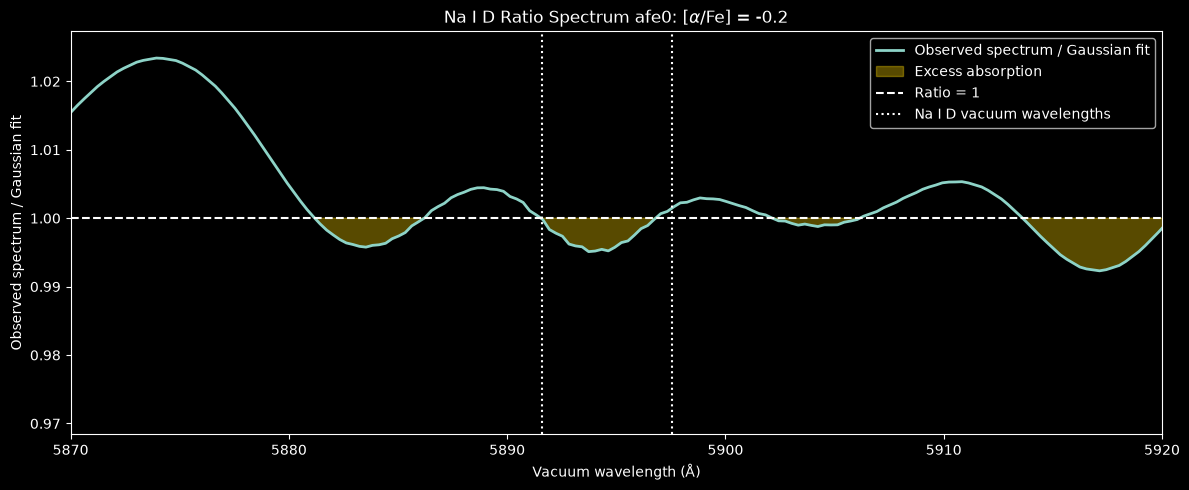

In [57]:
# ratio

# divide the observed normalized spectrum by the optimized Gaussian fit
ratio = normalized_flux / gauss_fit # creates a brand new array called ratio

# create a new figure for the ratio spectrum
plt.style.use("dark_background")
plt.figure(figsize = (12, 5))

# plot the ratio spectrum
plt.plot(
    region_wave, # region_wave is x-axis, contains vacuum wavelength
    ratio, # y-axis, contains observed normalized flux / optimized Gaussian fit
    linewidth = 2,
    label = "Observed spectrum / Gaussian fit"
)

# shade where the ratio is below 1
plt.fill_between( # (x, y1, y2)
    region_wave, # (x-values (x))
    ratio, # first y-curve (y1))
    1, # second y-curve (y2))
    where = (ratio < 1),
    interpolate = True,
    color = "gold",
    alpha = 0.35,
    label = "Excess absorption"
)

# Draw the reference level where the data and model match
plt.axhline( # horizontal = y
    1, # place the line at y = 1
    linestyle = "--",
    linewidth = 1.5,
    label = "Ratio = 1"
)

# Mark the blue Na I D wavelength
plt.axvline( # vertical = x
    5891.583, # x-axis
    linestyle = ":",
    linewidth = 1.5,
    label = "Na I D vacuum wavelengths"
)

# Mark the red Na I D wavelength
plt.axvline( # vertical = x
    5897.558, # x-axis
    linestyle = ":",
    linewidth = 1.5,
)

# zooms the x-axis
plt.xlim(5870, 5920)

# Labels the axes
plt.xlabel("Vacuum wavelength (Å)")
plt.ylabel("Observed spectrum / Gaussian fit")

plt.title(
    fr"Na I D Ratio Spectrum afe0: $[\alpha/\mathrm{{Fe}}]$ = {afe0:.1f}"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../Figures/Na I D Ratio Spectrum afe0.png",
    dpi = 300
)

plt.show()